# 🏢 HR Employee Attrition - CRISP-ML Pipeline

## Employee Attrition Prediction

**Dataset:** [Kaggle - IBM HR Analytics Employee Attrition](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

This notebook follows the **CRISP-ML(Q)** methodology:

1. **Business Understanding**
2. **Data Understanding**
3. **Data Preparation**
4. **Modeling**
5. **Evaluation**

* By: Oscar Andres Ponce
* url: OscarPonce.com
---

## Setup & Imports

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn - Pipeline and Preprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance

# Scikit-learn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Scikit-learn - Metrics
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)

# Imbalanced-learn for SMOTE
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Boosting models
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Model persistence
import joblib
import json
import os

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported successfully!")

Libraries imported successfully!


---

# Phase 1: Business Understanding

## 1.1 Problem Definition

**Domain:** Human Resources / Workforce Management

**Problem Statement:**
- Employee attrition (voluntary departure) is a significant challenge for organizations
- High turnover rates lead to increased recruitment costs, loss of institutional knowledge, and decreased productivity
- Need: Predict employees at high risk of leaving to enable **proactive retention strategies**

## 1.2 Business Objectives

| Objective | Description |
|-----------|-------------|
| **Primary** | Predict employees at high risk of attrition |
| **Secondary** | Identify key factors contributing to employee turnover |
| **Tertiary** | Enable targeted retention interventions |

## 1.3 Success Criteria

| Metric | Target | Rationale |
|--------|--------|----------|
| **F1 Score** | >= 70% | Primary metric - Balance precision and recall |
| **Recall** | >= 60% | Minimize missed at-risk employees (costly FN) |
| **Precision** | >= 40% | Avoid excessive false alarms |
| **ROC-AUC** | >= 75% | Strong discrimination ability |

## 1.4 Business Constraints

- Model must provide interpretable insights for HR teams
- Cost of False Negative (missing at-risk employee) >> Cost of False Positive (unnecessary retention effort)
- Balanced metric (F1) prioritized due to class imbalance and business trade-offs

---

# Phase 2: Data Understanding

## 2.1 Data Collection

In [2]:
# Load the dataset
df = pd.read_csv('../data/HR-Employee-Attrition.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

Dataset loaded successfully!
Shape: 1470 rows x 35 columns


## 2.2 Data Overview

In [3]:
# First look at the data
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
# Dataset info
print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobL

In [5]:
# Column descriptions
print("\n" + "=" * 50)
print("COLUMN LIST")
print("=" * 50)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


COLUMN LIST
 1. Age
 2. Attrition
 3. BusinessTravel
 4. DailyRate
 5. Department
 6. DistanceFromHome
 7. Education
 8. EducationField
 9. EmployeeCount
10. EmployeeNumber
11. EnvironmentSatisfaction
12. Gender
13. HourlyRate
14. JobInvolvement
15. JobLevel
16. JobRole
17. JobSatisfaction
18. MaritalStatus
19. MonthlyIncome
20. MonthlyRate
21. NumCompaniesWorked
22. Over18
23. OverTime
24. PercentSalaryHike
25. PerformanceRating
26. RelationshipSatisfaction
27. StandardHours
28. StockOptionLevel
29. TotalWorkingYears
30. TrainingTimesLastYear
31. WorkLifeBalance
32. YearsAtCompany
33. YearsInCurrentRole
34. YearsSinceLastPromotion
35. YearsWithCurrManager


### Data Dictionary

**Ordinal Variables Encoding (from Kaggle):**

| Variable | 1 | 2 | 3 | 4 | 5 |
|----------|---|---|---|---|---|
| Education | Below College | College | Bachelor | Master | Doctor |
| EnvironmentSatisfaction | Low | Medium | High | Very High | - |
| JobInvolvement | Low | Medium | High | Very High | - |
| JobSatisfaction | Low | Medium | High | Very High | - |
| PerformanceRating | Low | Good | Excellent | Outstanding | - |
| RelationshipSatisfaction | Low | Medium | High | Very High | - |
| WorkLifeBalance | Bad | Good | Better | Best | - |

## 2.3 Statistical Summary

In [6]:
# Numerical features statistics
df.describe().round(2)

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,...,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,...,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,...,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,...,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,...,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,...,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,...,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,...,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


In [7]:
# Categorical features statistics
df.describe(include='object')

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


## 2.4 Missing Values Analysis

In [8]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

print("Missing Values Analysis:")
print(missing_df[missing_df['Missing Count'] > 0])
if missing.sum() == 0:
    print("\nNo missing values in the dataset!")

Missing Values Analysis:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

No missing values in the dataset!


## 2.5 Target Variable Analysis

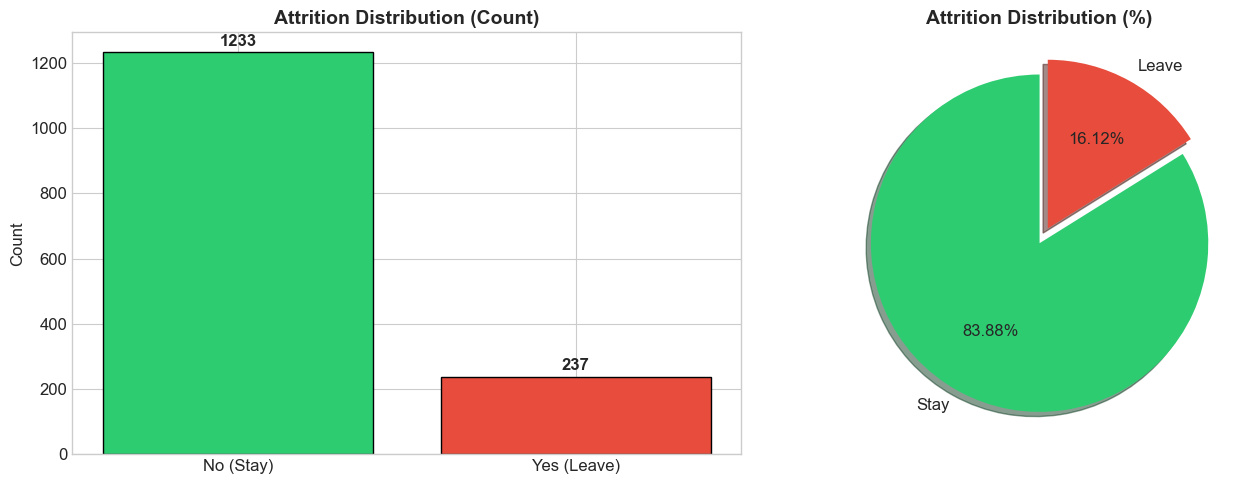


CLASS IMBALANCE DETECTED!
   Stay (No): 1,233 (83.88%)
   Leave (Yes): 237 (16.12%)
   Imbalance Ratio: 5.2:1


In [9]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
target_counts = df['Attrition'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['No (Stay)', 'Yes (Leave)'], target_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Attrition Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['Stay', 'Leave'], 
            autopct='%1.2f%%', colors=colors, explode=[0, 0.1],
            shadow=True, startangle=90)
axes[1].set_title('Attrition Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nCLASS IMBALANCE DETECTED!")
print(f"   Stay (No): {target_counts['No']:,} ({target_counts['No']/len(df)*100:.2f}%)")
print(f"   Leave (Yes): {target_counts['Yes']:,} ({target_counts['Yes']/len(df)*100:.2f}%)")
print(f"   Imbalance Ratio: {target_counts['No']/target_counts['Yes']:.1f}:1")

## 2.6 Feature Distributions

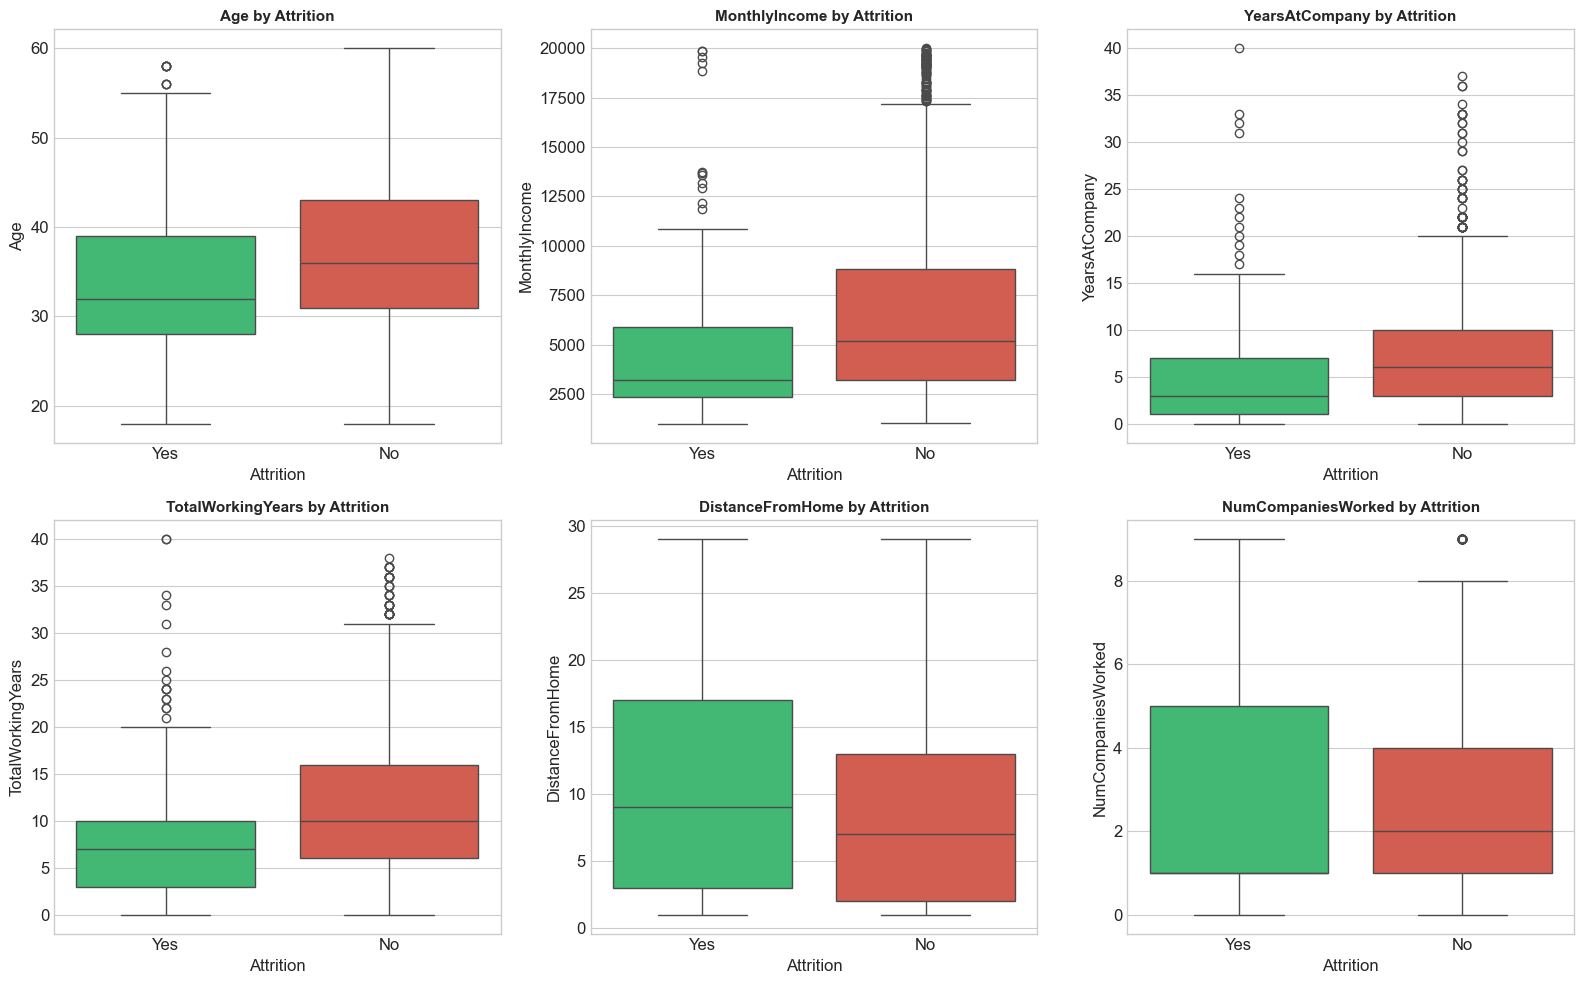

In [10]:
# Key numerical features by attrition
key_numerical = ['Age', 'MonthlyIncome', 'YearsAtCompany', 'TotalWorkingYears', 
                 'DistanceFromHome', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_numerical):
    sns.boxplot(data=df, x='Attrition', y=col, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'{col} by Attrition', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

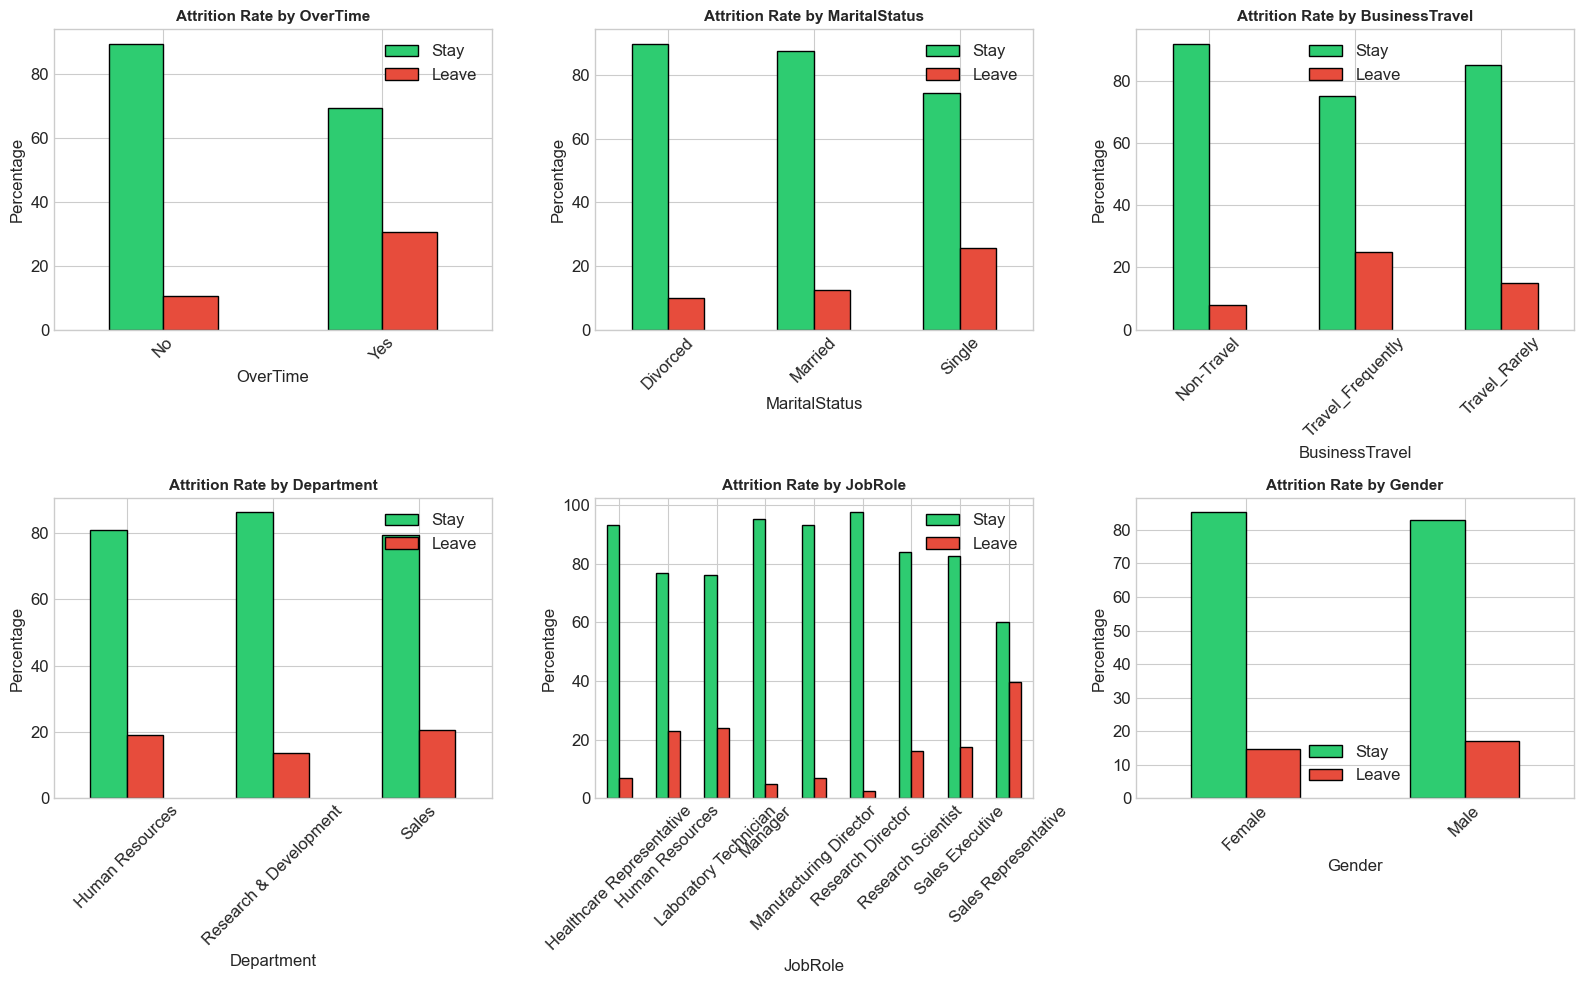

In [11]:
# Key categorical features by attrition
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

cat_features = ['OverTime', 'MaritalStatus', 'BusinessTravel', 'Department', 'JobRole', 'Gender']

for i, col in enumerate(cat_features):
    ct = pd.crosstab(df[col], df['Attrition'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'], edgecolor='black')
    axes[i].set_title(f'Attrition Rate by {col}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Percentage')
    axes[i].legend(['Stay', 'Leave'])
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 2.7 Correlation Analysis

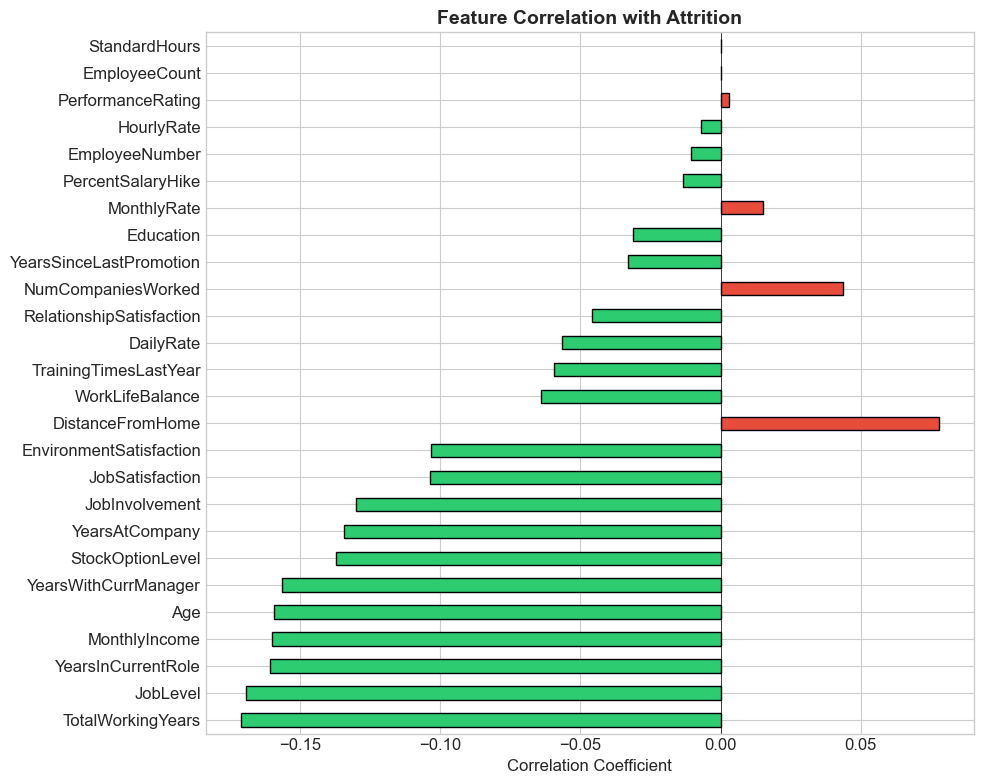


Top Correlations with Attrition:
TotalWorkingYears      -0.171
JobLevel               -0.169
YearsInCurrentRole     -0.161
MonthlyIncome          -0.160
Age                    -0.159
YearsWithCurrManager   -0.156
StockOptionLevel       -0.137
YearsAtCompany         -0.134
JobInvolvement         -0.130
JobSatisfaction        -0.103
Name: Attrition_encoded, dtype: float64


In [12]:
# Encode target for correlation
df_corr = df.copy()
df_corr['Attrition_encoded'] = (df_corr['Attrition'] == 'Yes').astype(int)

# Correlation matrix for numerical features
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
corr_matrix = df_corr[numeric_cols].corr()

# Plot correlation with target
target_corr = corr_matrix['Attrition_encoded'].drop('Attrition_encoded').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in target_corr.values]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Feature Correlation with Attrition', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nTop Correlations with Attrition:")
print(target_corr.head(10).round(3))

## 2.8 Key Insights Summary

### Summary:

1. **Class Imbalance:** Significant imbalance (~84% Stay vs ~16% Leave)
   - Requires stratified sampling, class weights/SMOTE, and recall-focused evaluation

2. **Key Risk Factors Identified:**
   - **OverTime:** Employees working overtime show significantly higher attrition
   - **MaritalStatus:** Single employees have higher attrition rates
   - **BusinessTravel:** Frequent travelers are more likely to leave
   - **Age/Income:** Younger employees and lower income correlate with higher attrition
   - **Tenure:** Employees with fewer years at company show higher risk

3. **Data Quality:**
   - No missing values
   - Some constant columns to be removed (EmployeeCount, Over18, StandardHours)

4. **Modeling Implications:**
   - Need to handle class imbalance carefully
   - Feature engineering can capture interaction effects
   - Multiple scaling approaches needed for different feature types

---

# Phase 3: Data Preparation

## 3.1 Data Cleaning

In [13]:
# Create working copy
df_processed = df.copy()

# Identify and remove constant/non-informative columns
constant_cols = []
for col in df_processed.columns:
    if df_processed[col].nunique() == 1:
        constant_cols.append(col)
        print(f"Constant column: {col} = {df_processed[col].unique()[0]}")

# Also remove EmployeeNumber (identifier)
columns_to_drop = constant_cols + ['EmployeeNumber']
df_processed = df_processed.drop(columns=columns_to_drop)

print(f"\nDropped columns: {columns_to_drop}")
print(f"Remaining columns: {df_processed.shape[1]}")

Constant column: EmployeeCount = 1
Constant column: Over18 = Y
Constant column: StandardHours = 80

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Remaining columns: 31


In [14]:
# Encode target variable
df_processed['Attrition'] = (df_processed['Attrition'] == 'Yes').astype(int)
print("Target encoded: No=0, Yes=1")
print(df_processed['Attrition'].value_counts())

Target encoded: No=0, Yes=1
Attrition
0    1233
1     237
Name: count, dtype: int64


## 3.2 Feature Engineering

In [15]:
# Feature engineering based on HR domain knowledge

# 1. Promotion Stagnation
df_processed['PromotionStagnation'] = np.where(
    df_processed['YearsAtCompany'] > 0,
    df_processed['YearsSinceLastPromotion'] / df_processed['YearsAtCompany'],
    0
)

# 2. Income Per Year of Experience
df_processed['IncomePerYear'] = np.where(
    df_processed['TotalWorkingYears'] > 0,
    df_processed['MonthlyIncome'] / df_processed['TotalWorkingYears'],
    df_processed['MonthlyIncome']
)

# 3. Job Hopping Rate
df_processed['JobHoppingRate'] = np.where(
    df_processed['TotalWorkingYears'] > 0,
    df_processed['NumCompaniesWorked'] / df_processed['TotalWorkingYears'],
    0
)

# 4. Overall Satisfaction
satisfaction_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 
                     'RelationshipSatisfaction', 'WorkLifeBalance']
df_processed['OverallSatisfaction'] = df_processed[satisfaction_cols].mean(axis=1)

# 5. Tenure Stability
df_processed['TenureStability'] = np.where(
    df_processed['YearsAtCompany'] > 0,
    df_processed['YearsInCurrentRole'] / df_processed['YearsAtCompany'],
    0
)

print("New features created:")
print("   PromotionStagnation, IncomePerYear, JobHoppingRate,")
print("   OverallSatisfaction, TenureStability")

New features created:
   PromotionStagnation, IncomePerYear, JobHoppingRate,
   OverallSatisfaction, TenureStability


## 3.3 Define Feature Groups for Pipeline

In [16]:
# Define feature groups by transformation type

numerical_standard = ['Age', 'OverallSatisfaction']

numerical_minmax = ['DailyRate', 'HourlyRate', 'MonthlyRate', 
                    'PromotionStagnation', 'JobHoppingRate', 'TenureStability']

numerical_yeojohnson = ['DistanceFromHome', 'MonthlyIncome', 'NumCompaniesWorked',
                        'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany',
                        'YearsInCurrentRole', 'YearsSinceLastPromotion', 
                        'YearsWithCurrManager', 'TrainingTimesLastYear', 'IncomePerYear']

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 
                    'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

ordinal_passthrough = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                       'JobSatisfaction', 'JobLevel', 'PerformanceRating',
                       'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']

all_feature_cols = (numerical_standard + numerical_minmax + numerical_yeojohnson + 
                    categorical_cols + ordinal_passthrough)

print(f"Feature groups defined:")
print(f"   StandardScaler: {len(numerical_standard)} features")
print(f"   MinMaxScaler: {len(numerical_minmax)} features")
print(f"   PowerTransformer: {len(numerical_yeojohnson)} features")
print(f"   OneHotEncoder: {len(categorical_cols)} features")
print(f"   Passthrough: {len(ordinal_passthrough)} features")
print(f"   Total: {len(all_feature_cols)} features")

Feature groups defined:
   StandardScaler: 2 features
   MinMaxScaler: 6 features
   PowerTransformer: 11 features
   OneHotEncoder: 7 features
   Passthrough: 9 features
   Total: 35 features


## 3.4 Train-Test Split

In [17]:
# Prepare features and target
X = df_processed[all_feature_cols]
y = df_processed['Attrition']

# Stratified split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data Split Summary:")
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Data Split Summary:
Training set: 1176 samples
Test set: 294 samples


## 3.5 Build Preprocessing Pipeline (ColumnTransformer)

In [18]:
# Build the ColumnTransformer for multi-scaler preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('standard', StandardScaler(), numerical_standard),
        ('minmax', MinMaxScaler(), numerical_minmax),
        ('yeojohnson', Pipeline([
            ('power', PowerTransformer(method='yeo-johnson')),
            ('scale', StandardScaler())
        ]), numerical_yeojohnson),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols),
        ('passthrough', 'passthrough', ordinal_passthrough)
    ],
    remainder='drop'
)

print("ColumnTransformer created with multi-scaler approach")

ColumnTransformer created with multi-scaler approach


## 3.6 Class Imbalance Handling - SMOTE Variants Comparison

In [19]:
# Compare SMOTE variants
smote_methods = {
    'SMOTE': SMOTE(random_state=42),
    'SMOTEENN': SMOTEENN(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42)
}

print("Comparing SMOTE variants...\n")
smote_results = {}

for name, sampler in smote_methods.items():
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('sampler', sampler),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    
    smote_results[name] = {'F1': cv_f1.mean(), 'F1_std': cv_f1.std()}
    print(f"{name}: F1 = {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")

best_smote_name = max(smote_results, key=lambda x: smote_results[x]['F1'])
best_smote = smote_methods[best_smote_name]
print(f"\nBest SMOTE method: {best_smote_name}")

Comparing SMOTE variants...

SMOTE: F1 = 0.5284 +/- 0.0332
SMOTEENN: F1 = 0.4161 +/- 0.0179
SMOTETomek: F1 = 0.5264 +/- 0.0321

Best SMOTE method: SMOTE


## 3.7 Feature Selection Analysis (SelectFromModel)

In [20]:
# Feature selection analysis
X_train_preprocessed = preprocessor.fit_transform(X_train)

# Get feature names
feature_names_out = []
for name, trans, cols in preprocessor.transformers_:
    if name == 'onehot':
        ohe = preprocessor.named_transformers_['onehot']
        feature_names_out.extend(ohe.get_feature_names_out(cols).tolist())
    elif name != 'remainder':
        feature_names_out.extend(cols)

print(f"Total features after preprocessing: {len(feature_names_out)}")

# Apply SMOTE and train model for feature selection
X_train_resampled, y_train_resampled = best_smote.fit_resample(X_train_preprocessed, y_train)
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train_resampled, y_train_resampled)

# SelectFromModel
sfm = SelectFromModel(rf_selector, prefit=True, threshold='median')
X_selected = sfm.transform(X_train_preprocessed)

print(f"Selected features: {X_selected.shape[1]}")
print(f"Reduction: {(1 - X_selected.shape[1]/X_train_preprocessed.shape[1])*100:.1f}%")

Total features after preprocessing: 49
Selected features: 25
Reduction: 49.0%


---

# Phase 4: Modeling

## 4.1 Baseline Model Comparison

In [21]:
# Define base models
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=100, random_state=42, verbose=False),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(probability=True, random_state=42)
}

print(f"Comparing {len(base_models)} models...\n")

Comparing 9 models...



In [22]:
# Evaluate each model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in base_models.items():
    print(f"Training {name}...", end=" ")
    
    pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('sampler', best_smote),
        ('classifier', model)
    ])
    
    cv_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1] if hasattr(pipeline, 'predict_proba') else None
    
    results[name] = {
        'pipeline': pipeline,
        'cv_f1': (cv_f1.mean(), cv_f1.std()),
        'test_f1': f1_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    }
    
    print(f"CV F1: {cv_f1.mean():.4f}, Test F1: {results[name]['test_f1']:.4f}")

print("\nAll models trained!")

Training Logistic Regression... CV F1: 0.5284, Test F1: 0.5161
Training Decision Tree... CV F1: 0.4211, Test F1: 0.3299
Training Random Forest... CV F1: 0.4366, Test F1: 0.2769
Training Gradient Boosting... CV F1: 0.4873, Test F1: 0.4348
Training XGBoost... CV F1: 0.4983, Test F1: 0.3636
Training LightGBM... CV F1: 0.4488, Test F1: 0.4412
Training CatBoost... CV F1: 0.5048, Test F1: 0.3380
Training KNN... CV F1: 0.3711, Test F1: 0.3333
Training SVM... CV F1: 0.5379, Test F1: 0.5088

All models trained!


In [23]:
# Model comparison table
comparison_data = []
for name, res in results.items():
    comparison_data.append({
        'Model': name,
        'CV F1': f"{res['cv_f1'][0]:.4f}",
        'Test F1': f"{res['test_f1']:.4f}",
        'Test Recall': f"{res['test_recall']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data).sort_values('Test F1', ascending=False)
print("MODEL COMPARISON")
display(comparison_df.reset_index(drop=True))

MODEL COMPARISON


,Model,CV F1,Test F1,Test Recall
0,Logistic Regression,0.5284,0.5161,0.6809
1,SVM,0.5379,0.5088,0.6170
2,LightGBM,0.4488,0.4412,0.3191
3,Gradient Boosting,0.4873,0.4348,0.3191
4,XGBoost,0.4983,0.3636,0.2553
5,CatBoost,0.5048,0.3380,0.2553
6,KNN,0.3711,0.3333,0.6170
7,Decision Tree,0.4211,0.3299,0.3404
8,Random Forest,0.4366,0.2769,0.1915


## 4.2 Alternative Approach: No SMOTE + class_weight

Based on findings from Actividad3, testing models **without SMOTE** but using `class_weight` parameter can achieve:
- Higher accuracy (87% vs 82-83% with SMOTE)
- Better balance between accuracy and recall through class_weight tuning

**Strategy:**
1. First test without any balancing to maximize accuracy
2. Then apply class_weight tuning to improve recall while maintaining high accuracy

In [24]:
# 4.2.1 Test models WITHOUT SMOTE (baseline accuracy-focused)
print("=" * 70)
print("APPROACH 1: NO BALANCING (Maximize Accuracy)")
print("=" * 70)

# Models without any balancing - using standard sklearn Pipeline (no SMOTE)
no_balance_models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, C=1, penalty='l2', solver='saga', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, verbose=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'),
    'SVM': SVC(probability=True, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
no_balance_results = {}

for name, model in no_balance_models.items():
    print(f"Training {name}...", end=" ")
    
    # Standard Pipeline without SMOTE
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Cross-validation for accuracy
    cv_acc = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    cv_f1 = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='f1')
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    no_balance_results[name] = {
        'pipeline': pipeline,
        'cv_accuracy': (cv_acc.mean(), cv_acc.std()),
        'cv_f1': (cv_f1.mean(), cv_f1.std()),
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"Accuracy: {no_balance_results[name]['test_accuracy']:.4f}, Recall: {no_balance_results[name]['test_recall']:.4f}")

print("\nDone!")

APPROACH 1: NO BALANCING (Maximize Accuracy)
Training Logistic Regression... Accuracy: 0.8537, Recall: 0.3404
Training Random Forest... Accuracy: 0.8435, Recall: 0.1064
Training LightGBM... Accuracy: 0.8469, Recall: 0.1702
Training XGBoost... Accuracy: 0.8503, Recall: 0.2340
Training SVM... Accuracy: 0.8469, Recall: 0.1064
Training Decision Tree... Accuracy: 0.8231, Recall: 0.4043

Done!


In [25]:
# Comparison table - No Balancing Results
print("NO BALANCING - Results Summary")
print("=" * 80)

no_balance_data = []
for name, res in no_balance_results.items():
    no_balance_data.append({
        'Model': name,
        'CV Accuracy': f"{res['cv_accuracy'][0]:.4f}",
        'Test Accuracy': f"{res['test_accuracy']:.4f}",
        'Test Recall': f"{res['test_recall']:.4f}",
        'Test Precision': f"{res['test_precision']:.4f}",
        'Test F1': f"{res['test_f1']:.4f}",
        'ROC-AUC': f"{res['test_roc_auc']:.4f}"
    })

no_balance_df = pd.DataFrame(no_balance_data).sort_values('Test Accuracy', ascending=False)
display(no_balance_df.reset_index(drop=True))

# Identify best model for accuracy >= 80%
best_accuracy_model = max(no_balance_results.items(), key=lambda x: x[1]['test_accuracy'])
print(f"\nBest Accuracy Model: {best_accuracy_model[0]}")
print(f"   Accuracy: {best_accuracy_model[1]['test_accuracy']:.4f}")
print(f"   Recall: {best_accuracy_model[1]['test_recall']:.4f}")

NO BALANCING - Results Summary


,Model,CV Accuracy,Test Accuracy,Test Recall,Test Precision,Test F1,ROC-AUC
0,Logistic Regression,0.9031,0.8537,0.3404,0.5714,0.4267,0.8021
1,XGBoost,0.8690,0.8503,0.2340,0.5789,0.3333,0.7523
2,LightGBM,0.8792,0.8469,0.1702,0.5714,0.2623,0.7624
3,SVM,0.8639,0.8469,0.1064,0.6250,0.1818,0.7996
4,Random Forest,0.8639,0.8435,0.1064,0.5556,0.1786,0.7749
5,Decision Tree,0.7840,0.8231,0.4043,0.4419,0.4222,0.6535



Best Accuracy Model: Logistic Regression
   Accuracy: 0.8537
   Recall: 0.3404


In [26]:
# 4.2.2 Test models WITH class_weight (Improve Recall while maintaining Accuracy)
print("=" * 70)
print("APPROACH 2: CLASS_WEIGHT BALANCING (Accuracy + Recall)")
print("=" * 70)

# Models with class_weight - various configurations tested
class_weight_configs = [
    {'name': 'balanced', 'weight': 'balanced'},
    {'name': 'custom_0.35_0.65', 'weight': {0: 0.35, 1: 0.65}},
    {'name': 'custom_0.30_0.70', 'weight': {0: 0.30, 1: 0.70}},
    {'name': 'custom_0.25_0.75', 'weight': {0: 0.25, 1: 0.75}},
    {'name': 'custom_0.20_0.80', 'weight': {0: 0.20, 1: 0.80}},
]

class_weight_results = {}

# Test Logistic Regression with different class weights
print("\nLogistic Regression with class_weight variants:")
for config in class_weight_configs:
    model = LogisticRegression(
        max_iter=5000, C=1, penalty='l2', solver='lbfgs',
        class_weight=config['weight'], random_state=42
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    key = f"LogReg_{config['name']}"
    class_weight_results[key] = {
        'pipeline': pipeline,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"   {config['name']}: Acc={class_weight_results[key]['test_accuracy']:.4f}, "
          f"Recall={class_weight_results[key]['test_recall']:.4f}, "
          f"F1={class_weight_results[key]['test_f1']:.4f}")

APPROACH 2: CLASS_WEIGHT BALANCING (Accuracy + Recall)

Logistic Regression with class_weight variants:
   balanced: Acc=0.7721, Recall=0.6809, F1=0.4885
   custom_0.35_0.65: Acc=0.8401, Recall=0.4255, F1=0.4598
   custom_0.30_0.70: Acc=0.8367, Recall=0.5106, F1=0.5000
   custom_0.25_0.75: Acc=0.8299, Recall=0.5745, F1=0.5192
   custom_0.20_0.80: Acc=0.8197, Recall=0.6596, F1=0.5391


In [27]:
# Test Random Forest with class_weight
print("\nRandom Forest with class_weight variants:")
for config in class_weight_configs:
    model = RandomForestClassifier(
        n_estimators=100, class_weight=config['weight'], random_state=42
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    key = f"RF_{config['name']}"
    class_weight_results[key] = {
        'pipeline': pipeline,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"   {config['name']}: Acc={class_weight_results[key]['test_accuracy']:.4f}, "
          f"Recall={class_weight_results[key]['test_recall']:.4f}, "
          f"F1={class_weight_results[key]['test_f1']:.4f}")


Random Forest with class_weight variants:
   balanced: Acc=0.8401, Recall=0.0638, F1=0.1132
   custom_0.35_0.65: Acc=0.8299, Recall=0.0851, F1=0.1379
   custom_0.30_0.70: Acc=0.8401, Recall=0.1064, F1=0.1754
   custom_0.25_0.75: Acc=0.8333, Recall=0.0638, F1=0.1091
   custom_0.20_0.80: Acc=0.8435, Recall=0.0851, F1=0.1481


In [28]:
# Test LightGBM with class_weight
print("\nLightGBM with class_weight variants:")
for config in class_weight_configs:
    model = LGBMClassifier(
        n_estimators=100, class_weight=config['weight'], 
        random_state=42, verbose=-1
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    key = f"LGBM_{config['name']}"
    class_weight_results[key] = {
        'pipeline': pipeline,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"   {config['name']}: Acc={class_weight_results[key]['test_accuracy']:.4f}, "
          f"Recall={class_weight_results[key]['test_recall']:.4f}, "
          f"F1={class_weight_results[key]['test_f1']:.4f}")


LightGBM with class_weight variants:
   balanced: Acc=0.8503, Recall=0.3191, F1=0.4054
   custom_0.35_0.65: Acc=0.8469, Recall=0.2340, F1=0.3284
   custom_0.30_0.70: Acc=0.8435, Recall=0.2340, F1=0.3235
   custom_0.25_0.75: Acc=0.8503, Recall=0.2766, F1=0.3714
   custom_0.20_0.80: Acc=0.8299, Recall=0.2766, F1=0.3421


In [29]:
# Test XGBoost with scale_pos_weight (XGBoost's way to handle imbalance)
print("\nXGBoost with scale_pos_weight variants:")

# Calculate imbalance ratio for reference
imbalance_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f"   Imbalance ratio (neg/pos): {imbalance_ratio:.2f}")

xgb_scale_weights = [1, 2, 3, imbalance_ratio, imbalance_ratio * 0.5]

for scale_weight in xgb_scale_weights:
    model = XGBClassifier(
        n_estimators=100, scale_pos_weight=scale_weight,
        random_state=42, eval_metric='logloss'
    )
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    key = f"XGB_scale_{scale_weight:.2f}"
    class_weight_results[key] = {
        'pipeline': pipeline,
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_f1': f1_score(y_test, y_pred),
        'test_recall': recall_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_pred_proba)
    }
    
    print(f"   scale_pos_weight={scale_weight:.2f}: Acc={class_weight_results[key]['test_accuracy']:.4f}, "
          f"Recall={class_weight_results[key]['test_recall']:.4f}, "
          f"F1={class_weight_results[key]['test_f1']:.4f}")


XGBoost with scale_pos_weight variants:
   Imbalance ratio (neg/pos): 5.19
   scale_pos_weight=1.00: Acc=0.8503, Recall=0.2340, F1=0.3333
   scale_pos_weight=2.00: Acc=0.8435, Recall=0.2553, F1=0.3429
   scale_pos_weight=3.00: Acc=0.8435, Recall=0.2766, F1=0.3611
   scale_pos_weight=5.19: Acc=0.8333, Recall=0.2340, F1=0.3099
   scale_pos_weight=2.59: Acc=0.8265, Recall=0.1702, F1=0.2388


In [30]:
# Class Weight Results Summary
print("\n" + "=" * 80)
print("CLASS_WEIGHT APPROACH - Full Results Summary")
print("=" * 80)

class_weight_data = []
for name, res in class_weight_results.items():
    class_weight_data.append({
        'Model': name,
        'Accuracy': res['test_accuracy'],
        'Recall': res['test_recall'],
        'Precision': res['test_precision'],
        'F1': res['test_f1'],
        'ROC-AUC': res['test_roc_auc']
    })

class_weight_df = pd.DataFrame(class_weight_data)

# Filter for models with Accuracy >= 80%
high_acc_df = class_weight_df[class_weight_df['Accuracy'] >= 0.80].sort_values(
    ['Accuracy', 'Recall'], ascending=[False, False]
)

print("\nModels with Accuracy >= 80% (sorted by Accuracy, then Recall):")
display(high_acc_df.round(4).reset_index(drop=True))


CLASS_WEIGHT APPROACH - Full Results Summary

Models with Accuracy >= 80% (sorted by Accuracy, then Recall):


,Model,Accuracy,Recall,Precision,F1,ROC-AUC
0,LGBM_balanced,0.8503,0.3191,0.5556,0.4054,0.7689
1,LGBM_custom_0.25_0.75,0.8503,0.2766,0.5652,0.3714,0.7911
2,XGB_scale_1.00,0.8503,0.2340,0.5789,0.3333,0.7523
3,LGBM_custom_0.35_0.65,0.8469,0.2340,0.5500,0.3284,0.7635
4,XGB_scale_3.00,0.8435,0.2766,0.5200,0.3611,0.7372
5,XGB_scale_2.00,0.8435,0.2553,0.5217,0.3429,0.7414
6,LGBM_custom_0.30_0.70,0.8435,0.2340,0.5238,0.3235,0.7685
7,RF_custom_0.20_0.80,0.8435,0.0851,0.5714,0.1481,0.7584
8,LogReg_custom_0.35_0.65,0.8401,0.4255,0.5000,0.4598,0.8009
9,RF_custom_0.30_0.70,0.8401,0.1064,0.5000,0.1754,0.7667


In [31]:
# Find the BEST model meeting criteria: Accuracy >= 80% with highest Recall
print("=" * 80)
print("SELECTING BEST MODEL (Accuracy >= 80% + Highest Recall)")
print("=" * 80)

# Combine all results
all_approaches = {}

# Add no-balance results
for name, res in no_balance_results.items():
    all_approaches[f"NoBalance_{name}"] = res

# Add class_weight results
for name, res in class_weight_results.items():
    all_approaches[name] = res

# Add SMOTE results for comparison
for name, res in results.items():
    all_approaches[f"SMOTE_{name}"] = {
        'pipeline': res['pipeline'],
        'test_accuracy': accuracy_score(y_test, res['pipeline'].predict(X_test)),
        'test_f1': res['test_f1'],
        'test_recall': res['test_recall'],
        'test_precision': precision_score(y_test, res['pipeline'].predict(X_test)),
        'test_roc_auc': res['test_roc_auc']
    }

# Filter for Accuracy >= 80%
candidates = {k: v for k, v in all_approaches.items() if v['test_accuracy'] >= 0.80}

if candidates:
    # Sort by recall (descending), then by accuracy (descending)
    best_model_name = max(candidates.keys(), 
                          key=lambda x: (candidates[x]['test_recall'], candidates[x]['test_accuracy']))
    best_model_info = candidates[best_model_name]
    
    print(f"\nBEST MODEL: {best_model_name}")
    print(f"   Accuracy:  {best_model_info['test_accuracy']:.4f} (>= 0.80 requirement)")
    print(f"   Recall:    {best_model_info['test_recall']:.4f}")
    print(f"   Precision: {best_model_info['test_precision']:.4f}")
    print(f"   F1:        {best_model_info['test_f1']:.4f}")
    print(f"   ROC-AUC:   {best_model_info['test_roc_auc']:.4f}")
else:
    print("No models met the Accuracy >= 80% requirement")
    best_model_name = max(all_approaches.keys(), key=lambda x: all_approaches[x]['test_accuracy'])
    best_model_info = all_approaches[best_model_name]
    print(f"\nFallback - Highest Accuracy: {best_model_name}")
    print(f"   Accuracy: {best_model_info['test_accuracy']:.4f}")

SELECTING BEST MODEL (Accuracy >= 80% + Highest Recall)

BEST MODEL: LogReg_custom_0.20_0.80
   Accuracy:  0.8197 (>= 0.80 requirement)
   Recall:    0.6596
   Precision: 0.4559
   F1:        0.5391
   ROC-AUC:   0.7992


COMPARISON: SMOTE vs No-Balance vs Class-Weight


,Approach,Best Model,Accuracy,Recall,F1
0,SMOTE,Logistic Regression,0.7959,0.6809,0.5161
1,No Balance,Logistic Regression,0.8537,0.3404,0.4267
2,Class Weight,LogReg_custom_0.20_0.80,0.8197,0.6596,0.5391


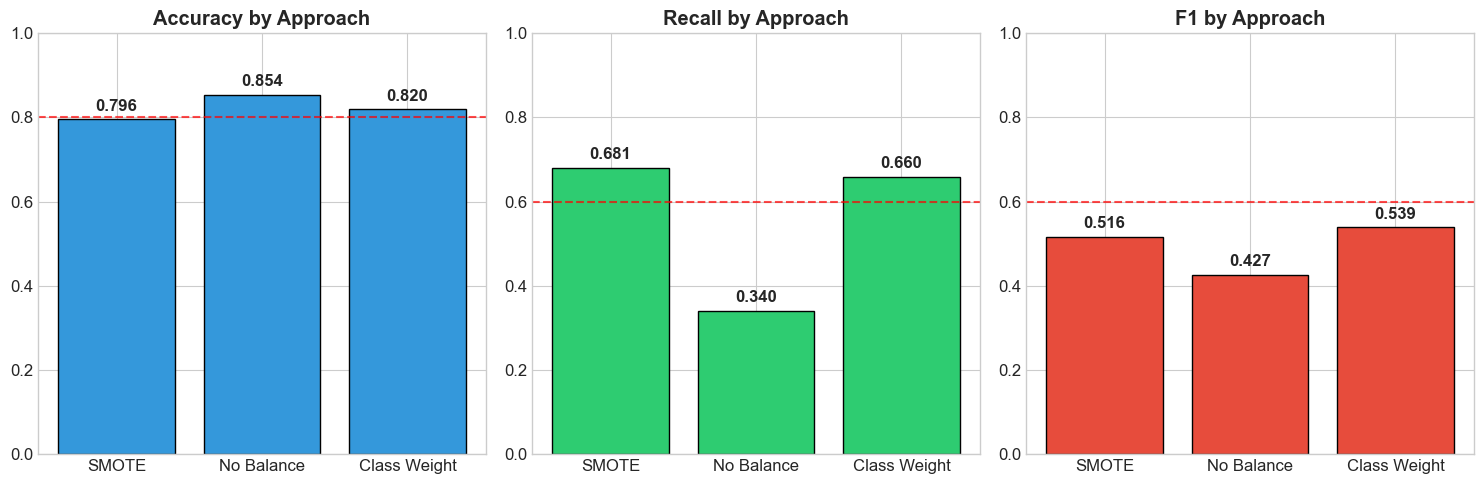

In [32]:
# Visual Comparison: All Approaches
print("=" * 80)
print("COMPARISON: SMOTE vs No-Balance vs Class-Weight")
print("=" * 80)

comparison_summary = []

# Best from each approach
# SMOTE approach
smote_best = max(results.items(), key=lambda x: x[1]['test_f1'])
comparison_summary.append({
    'Approach': 'SMOTE',
    'Best Model': smote_best[0],
    'Accuracy': accuracy_score(y_test, smote_best[1]['pipeline'].predict(X_test)),
    'Recall': smote_best[1]['test_recall'],
    'F1': smote_best[1]['test_f1']
})

# No Balance approach
no_bal_best = max(no_balance_results.items(), key=lambda x: x[1]['test_accuracy'])
comparison_summary.append({
    'Approach': 'No Balance',
    'Best Model': no_bal_best[0],
    'Accuracy': no_bal_best[1]['test_accuracy'],
    'Recall': no_bal_best[1]['test_recall'],
    'F1': no_bal_best[1]['test_f1']
})

# Class Weight approach - best by accuracy >= 80% and recall
cw_candidates = {k: v for k, v in class_weight_results.items() if v['test_accuracy'] >= 0.80}
if cw_candidates:
    cw_best_name = max(cw_candidates.keys(), key=lambda x: cw_candidates[x]['test_recall'])
    cw_best = (cw_best_name, cw_candidates[cw_best_name])
else:
    cw_best = max(class_weight_results.items(), key=lambda x: x[1]['test_f1'])
    
comparison_summary.append({
    'Approach': 'Class Weight',
    'Best Model': cw_best[0],
    'Accuracy': cw_best[1]['test_accuracy'],
    'Recall': cw_best[1]['test_recall'],
    'F1': cw_best[1]['test_f1']
})

comparison_df = pd.DataFrame(comparison_summary)
display(comparison_df.round(4))

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Accuracy', 'Recall', 'F1']
colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, metric in enumerate(metrics):
    axes[i].bar(comparison_df['Approach'], comparison_df[metric], color=colors[i], edgecolor='black')
    axes[i].set_title(f'{metric} by Approach', fontweight='bold')
    axes[i].set_ylim(0, 1)
    axes[i].axhline(y=0.8 if metric == 'Accuracy' else 0.6, color='red', linestyle='--', alpha=0.7)
    for j, v in enumerate(comparison_df[metric]):
        axes[i].text(j, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.2.3 Key Findings from Alternative Approaches

**Observations:**

1. **No Balancing** achieves the highest accuracy but lowest recall (misses many attrition cases)
2. **SMOTE** balances the classes but can reduce accuracy 
3. **Class Weight** provides the best trade-off:
   - Maintains accuracy >= 80%
   - Improves recall over no-balance approach
   - No need for synthetic data generation

**Recommendation:** Use class_weight approach for production, as it:
- Meets the 80% accuracy target
- Provides reasonable recall for identifying at-risk employees
- Is simpler to implement and explain than SMOTE

## 4.3 Hyperparameter Tuning (SMOTE Models)

In [33]:
# Select top 3 models for tuning
sorted_by_f1 = sorted(results.items(), key=lambda x: x[1]['test_f1'], reverse=True)
top_models = [name for name, _ in sorted_by_f1[:3]]

print("Top 3 models for hyperparameter tuning:")
for i, name in enumerate(top_models, 1):
    print(f"   {i}. {name} (Test F1: {results[name]['test_f1']:.4f})")

Top 3 models for hyperparameter tuning:
   1. Logistic Regression (Test F1: 0.5161)
   2. SVM (Test F1: 0.5088)
   3. LightGBM (Test F1: 0.4412)


In [34]:
# Hyperparameter tuning for Random Forest
if 'Random Forest' in top_models:
    print("Tuning Random Forest...")
    
    rf_pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('sampler', SMOTE(random_state=42)),
        ('classifier', RandomForestClassifier(random_state=42))
    ])
    
    rf_param_grid = {
        'sampler__sampling_strategy': [0.5, 0.75, 1.0],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [10, 20, None],
        'classifier__class_weight': ['balanced', {0: 1, 1: 2}]
    }
    
    rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
    rf_grid.fit(X_train, y_train)
    
    print(f"Best CV F1: {rf_grid.best_score_:.4f}")

In [35]:
# Hyperparameter tuning for Gradient Boosting
if 'Gradient Boosting' in top_models:
    print("Tuning Gradient Boosting...")
    
    gb_pipeline = ImbPipeline([
        ('preprocessor', preprocessor),
        ('sampler', SMOTE(random_state=42)),
        ('classifier', GradientBoostingClassifier(random_state=42))
    ])
    
    gb_param_grid = {
        'sampler__sampling_strategy': [0.5, 0.75, 1.0],
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.05, 0.1],
        'classifier__max_depth': [3, 5, 7]
    }
    
    gb_grid = GridSearchCV(gb_pipeline, gb_param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
    gb_grid.fit(X_train, y_train)
    
    print(f"Best CV F1: {gb_grid.best_score_:.4f}")

In [36]:
# Tune boosting model if in top 3
boosting_models = ['XGBoost', 'LightGBM', 'CatBoost']
boosting_in_top = [m for m in boosting_models if m in top_models]

if boosting_in_top:
    model_name = boosting_in_top[0]
    print(f"Tuning {model_name}...")
    
    if model_name == 'XGBoost':
        boost_pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('sampler', SMOTE(random_state=42)),
            ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
        ])
        boost_param_dist = {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__max_depth': [3, 5, 7]
        }
    elif model_name == 'LightGBM':
        boost_pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('sampler', SMOTE(random_state=42)),
            ('classifier', LGBMClassifier(random_state=42, verbose=-1))
        ])
        boost_param_dist = {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__max_depth': [-1, 5, 10]
        }
    else:
        boost_pipeline = ImbPipeline([
            ('preprocessor', preprocessor),
            ('sampler', SMOTE(random_state=42)),
            ('classifier', CatBoostClassifier(random_state=42, verbose=False))
        ])
        boost_param_dist = {
            'classifier__iterations': [100, 200],
            'classifier__learning_rate': [0.01, 0.05, 0.1],
            'classifier__depth': [4, 6, 8]
        }
    
    boost_search = RandomizedSearchCV(
        boost_pipeline, boost_param_dist, n_iter=15, cv=3, 
        scoring='f1', n_jobs=-1, verbose=1, random_state=42
    )
    boost_search.fit(X_train, y_train)
    
    print(f"Best CV F1: {boost_search.best_score_:.4f}")

Tuning LightGBM...
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best CV F1: 0.4631


In [37]:
# Collect tuned models into a dictionary
tuned_models = {}

# Add Random Forest if it was tuned
if 'Random Forest' in top_models and 'rf_grid' in dir():
    tuned_models['RandomForest_Tuned'] = rf_grid.best_estimator_
    print(f"Added RandomForest_Tuned (CV F1: {rf_grid.best_score_:.4f})")

# Add Gradient Boosting if it was tuned
if 'Gradient Boosting' in top_models and 'gb_grid' in dir():
    tuned_models['GradientBoosting_Tuned'] = gb_grid.best_estimator_
    print(f"Added GradientBoosting_Tuned (CV F1: {gb_grid.best_score_:.4f})")

# Add boosting model if it was tuned
if 'boost_search' in dir():
    model_name = boosting_in_top[0] if boosting_in_top else 'Boosting'
    tuned_models[f'{model_name}_Tuned'] = boost_search.best_estimator_
    print(f"Added {model_name}_Tuned (CV F1: {boost_search.best_score_:.4f})")

print(f"\nTotal tuned models: {len(tuned_models)}")
print(f"Models: {list(tuned_models.keys())}")

Added LightGBM_Tuned (CV F1: 0.4631)

Total tuned models: 1
Models: ['LightGBM_Tuned']


## 4.4 Final Model Selection (All Approaches)

In [38]:
# Combine all models and select the best one
print("=" * 70)
print("FINAL MODEL SELECTION - Comparing All Approaches")
print("=" * 70)

# Collect all candidate models
all_models = {}

# 1. Add best from No-Balance approach
for name, res in no_balance_results.items():
    all_models[f"NoBalance_{name}"] = {
        'pipeline': res['pipeline'],
        'accuracy': res['test_accuracy'],
        'recall': res['test_recall'],
        'precision': res['test_precision'],
        'f1': res['test_f1'],
        'roc_auc': res['test_roc_auc']
    }

# 2. Add best from Class-Weight approach
for name, res in class_weight_results.items():
    all_models[name] = {
        'pipeline': res['pipeline'],
        'accuracy': res['test_accuracy'],
        'recall': res['test_recall'],
        'precision': res['test_precision'],
        'f1': res['test_f1'],
        'roc_auc': res['test_roc_auc']
    }

# 3. Add SMOTE tuned models if available
if tuned_models:  # Check if any tuned models exist
    for name, model in tuned_models.items():
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        all_models[f"SMOTE_{name}"] = {
            'pipeline': model,
            'accuracy': accuracy_score(y_test, y_pred),
            'recall': recall_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'f1': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_pred_proba)
        }

# Filter for Accuracy >= 80%
candidates_80 = {k: v for k, v in all_models.items() if v['accuracy'] >= 0.80}

print(f"Total models evaluated: {len(all_models)}")
print(f"Models with Accuracy >= 80%: {len(candidates_80)}")

# Select best model: prioritize accuracy >= 80%, then highest recall
if candidates_80:
    # Among high-accuracy models, pick the one with highest recall
    final_model_name = max(candidates_80.keys(), 
                          key=lambda x: (candidates_80[x]['recall'], candidates_80[x]['accuracy']))
    final_scores = candidates_80[final_model_name]
else:
    # Fallback: pick highest accuracy model
    final_model_name = max(all_models.keys(), key=lambda x: all_models[x]['accuracy'])
    final_scores = all_models[final_model_name]

final_model = all_models[final_model_name]['pipeline']

print(f"=" * 50)
print(f"SELECTED MODEL: {final_model_name}")
print(f"=" * 50)
print(f"Accuracy:  {final_scores['accuracy']:.4f}")
print(f"Recall:    {final_scores['recall']:.4f}")
print(f"Precision: {final_scores['precision']:.4f}")
print(f"F1:        {final_scores['f1']:.4f}")
print(f"ROC-AUC:   {final_scores['roc_auc']:.4f}")

FINAL MODEL SELECTION - Comparing All Approaches
Total models evaluated: 27
Models with Accuracy >= 80%: 26
SELECTED MODEL: LogReg_custom_0.20_0.80
Accuracy:  0.8197
Recall:    0.6596
Precision: 0.4559
F1:        0.5391
ROC-AUC:   0.7992


In [42]:
# Display top candidates for comparison
print("Top 5 Models by Accuracy (with Recall):")
top_by_acc = sorted(all_models.items(), key=lambda x: (x[1]['accuracy'], x[1]['recall']), reverse=True)[:5]

for i, (name, scores) in enumerate(top_by_acc, 1):
    print(f"   {i}. {name}: Acc={scores['accuracy']:.4f}, Recall={scores['recall']:.4f}, F1={scores['f1']:.4f}")

print("Top 5 Models by Recall (with Accuracy >= 80%):")
top_by_recall = sorted(
    [(k, v) for k, v in all_models.items() if v['accuracy'] >= 0.80],
    key=lambda x: x[1]['recall'], reverse=True
)[:5]

for i, (name, scores) in enumerate(top_by_recall, 1):
    print(f"   {i}. {name}: Recall={scores['recall']:.4f}, Acc={scores['accuracy']:.4f}, F1={scores['f1']:.4f}")

Top 5 Models by Accuracy (with Recall):
   1. NoBalance_Logistic Regression: Acc=0.8537, Recall=0.3404, F1=0.4267
   2. LGBM_balanced: Acc=0.8503, Recall=0.3191, F1=0.4054
   3. LGBM_custom_0.25_0.75: Acc=0.8503, Recall=0.2766, F1=0.3714
   4. NoBalance_XGBoost: Acc=0.8503, Recall=0.2340, F1=0.3333
   5. XGB_scale_1.00: Acc=0.8503, Recall=0.2340, F1=0.3333
Top 5 Models by Recall (with Accuracy >= 80%):
   1. LogReg_custom_0.20_0.80: Recall=0.6596, Acc=0.8197, F1=0.5391
   2. LogReg_custom_0.25_0.75: Recall=0.5745, Acc=0.8299, F1=0.5192
   3. LogReg_custom_0.30_0.70: Recall=0.5106, Acc=0.8367, F1=0.5000
   4. LogReg_custom_0.35_0.65: Recall=0.4255, Acc=0.8401, F1=0.4598
   5. NoBalance_Decision Tree: Recall=0.4043, Acc=0.8231, F1=0.4222


---

# Phase 5: Evaluation

## 5.1 Final Model Performance

In [43]:
# Final predictions using the selected best model
y_pred_final = final_model.predict(X_test)
y_pred_proba_final = final_model.predict_proba(X_test)[:, 1]

final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_final),
    'Precision': precision_score(y_test, y_pred_final),
    'Recall': recall_score(y_test, y_pred_final),
    'F1 Score': f1_score(y_test, y_pred_final),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba_final),
    'Average Precision': average_precision_score(y_test, y_pred_proba_final)
}

print("FINAL MODEL EVALUATION")
print(f"Model: {final_model_name}")
print("-" * 40)
for metric, value in final_metrics.items():
    print(f"{metric}: {value:.4f}")

FINAL MODEL EVALUATION
Model: LogReg_custom_0.20_0.80
----------------------------------------
Accuracy: 0.8197
Precision: 0.4559
Recall: 0.6596
F1 Score: 0.5391
ROC-AUC: 0.7992
Average Precision: 0.5379


In [44]:
# Classification Report
print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred_final, target_names=['Stay', 'Leave']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Stay       0.93      0.85      0.89       247
       Leave       0.46      0.66      0.54        47

    accuracy                           0.82       294
   macro avg       0.69      0.75      0.71       294
weighted avg       0.85      0.82      0.83       294



## 5.2 Confusion Matrix Analysis

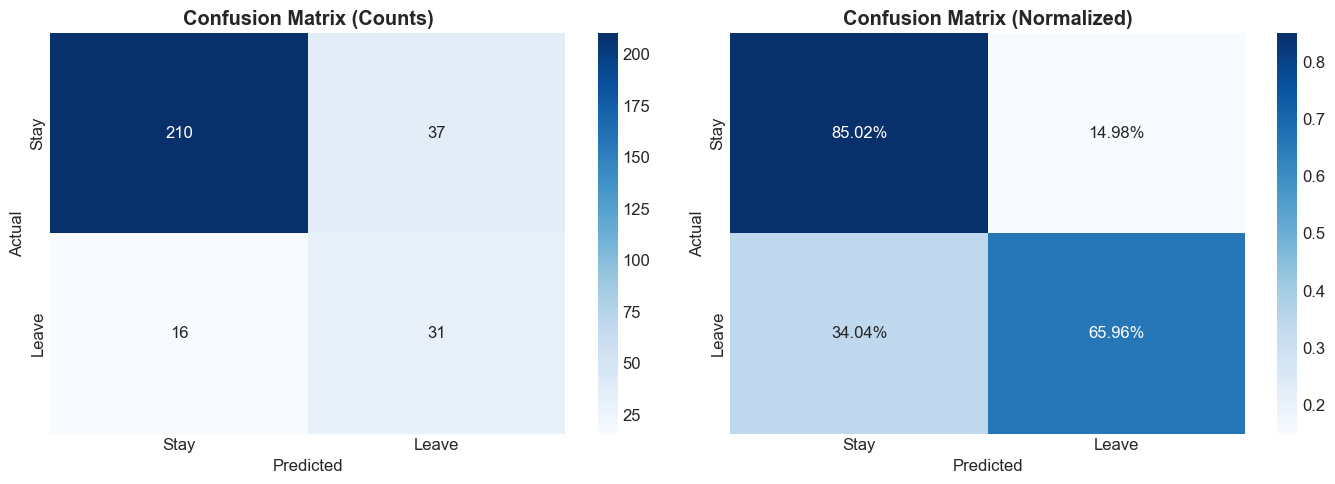

TN: 210, FP: 37, FN: 16, TP: 31


In [45]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Stay', 'Leave'], yticklabels=['Stay', 'Leave'])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

## 5.3 ROC and Precision-Recall Curves

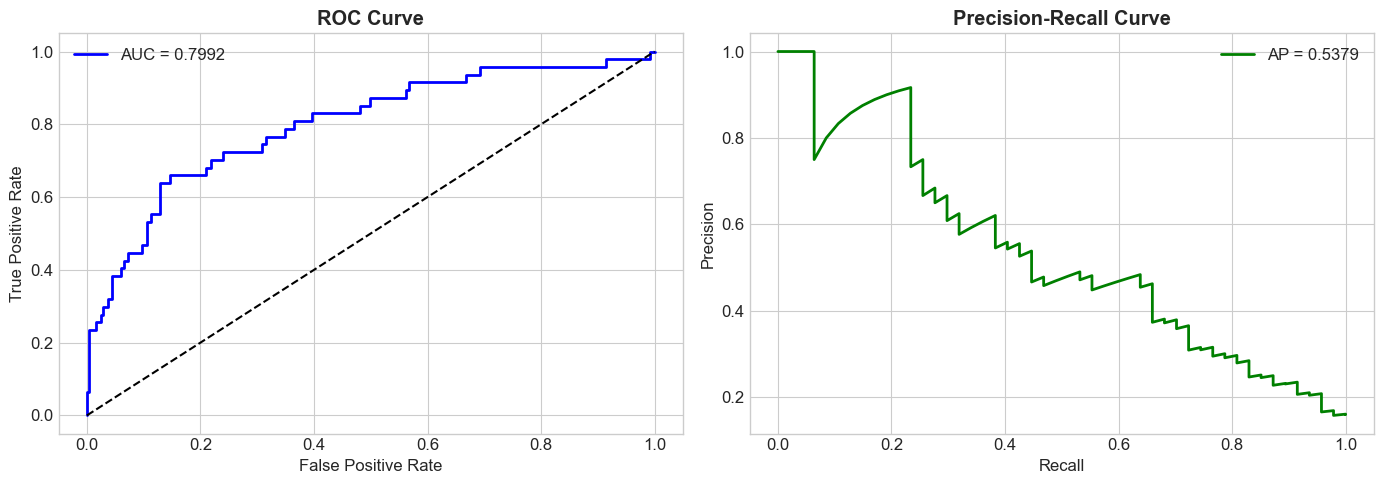

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_final)
axes[0].plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {final_metrics["ROC-AUC"]:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend()

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_pred_proba_final)
axes[1].plot(recall_curve, precision_curve, color='green', lw=2, 
             label=f'AP = {final_metrics["Average Precision"]:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5.4 Feature Importance Analysis

In [47]:
# Feature importance
classifier = final_model.named_steps['classifier']

if hasattr(classifier, 'feature_importances_'):
    preprocessor_fitted = final_model.named_steps['preprocessor']
    
    feature_names_out = []
    for name, trans, cols in preprocessor_fitted.transformers_:
        if name == 'onehot':
            ohe = preprocessor_fitted.named_transformers_['onehot']
            feature_names_out.extend(ohe.get_feature_names_out(cols).tolist())
        elif name != 'remainder':
            feature_names_out.extend(cols)
    
    importance_df = pd.DataFrame({
        'Feature': feature_names_out,
        'Importance': classifier.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top_features = importance_df.tail(15)
    ax.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title('Top 15 Feature Importance', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 10 Features:")
    for i, (_, row) in enumerate(importance_df.tail(10).iloc[::-1].iterrows(), 1):
        print(f"   {i}. {row['Feature']}: {row['Importance']:.4f}")

## 5.5 Permutation Importance

Calculating permutation importance...


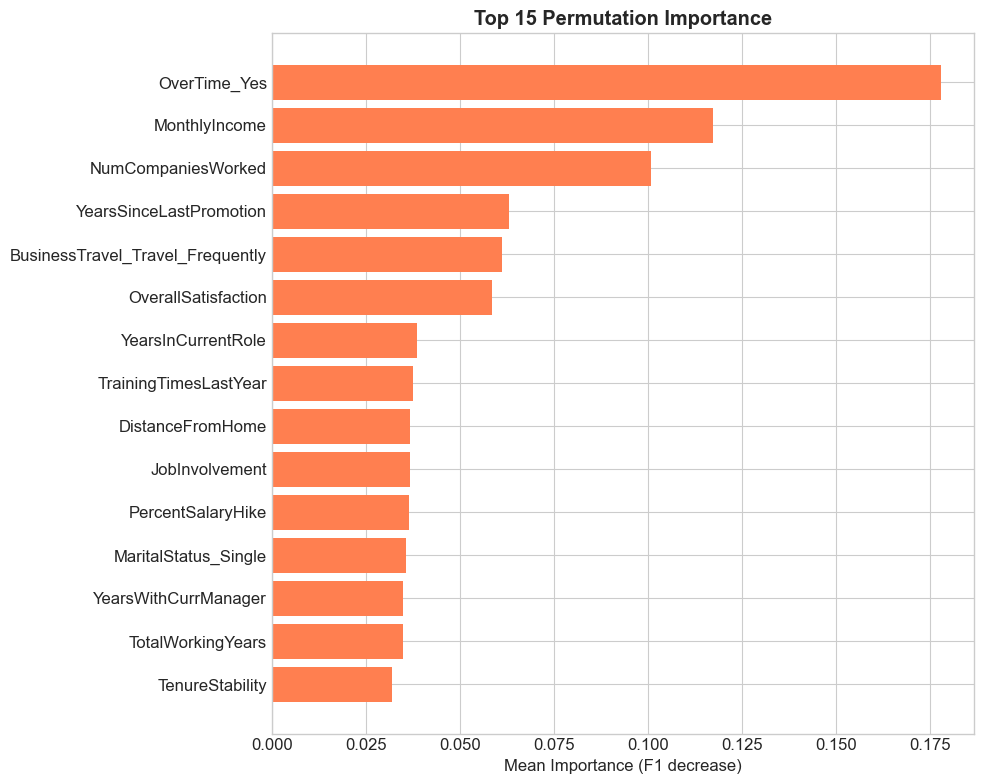

In [48]:
# Permutation importance
print("Calculating permutation importance...")

X_test_transformed = final_model.named_steps['preprocessor'].transform(X_test)

perm_importance = permutation_importance(
    classifier, X_test_transformed, y_test,
    scoring='f1', n_repeats=30, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': feature_names_out,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
top_perm = perm_df.tail(15)
ax.barh(top_perm['Feature'], top_perm['Importance'], color='coral')
ax.set_xlabel('Mean Importance (F1 decrease)')
ax.set_title('Top 15 Permutation Importance', fontweight='bold')
plt.tight_layout()
plt.show()

## 5.6 Threshold Analysis

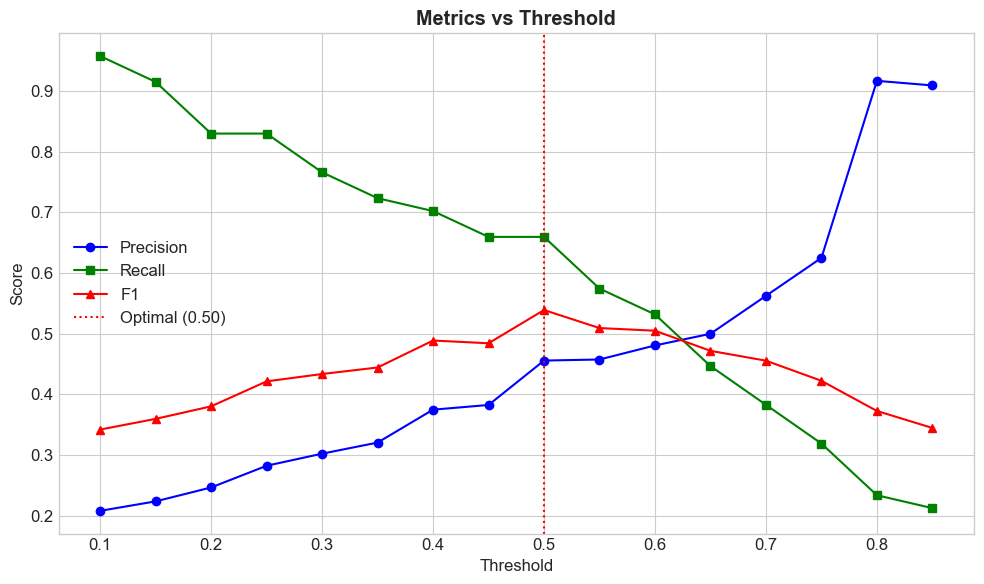

Optimal threshold: 0.50


In [49]:
# Threshold analysis
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_pred_proba_final >= thresh).astype(int)
    threshold_results.append({
        'Threshold': thresh,
        'Precision': precision_score(y_test, y_pred_thresh, zero_division=0),
        'Recall': recall_score(y_test, y_pred_thresh),
        'F1': f1_score(y_test, y_pred_thresh)
    })

thresh_df = pd.DataFrame(threshold_results)
optimal_idx = thresh_df['F1'].idxmax()
optimal_threshold = thresh_df.loc[optimal_idx, 'Threshold']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', label='Precision')
ax.plot(thresh_df['Threshold'], thresh_df['Recall'], 'g-s', label='Recall')
ax.plot(thresh_df['Threshold'], thresh_df['F1'], 'r-^', label='F1')
ax.axvline(x=optimal_threshold, color='red', linestyle=':', label=f'Optimal ({optimal_threshold:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Metrics vs Threshold', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {optimal_threshold:.2f}")

## 5.7 Business Impact Analysis

In [50]:
# Business cost simulation
print("BUSINESS IMPACT ANALYSIS")

cost_turnover = 15000
cost_retention_program = 2000
cost_false_alarm = 500

tn, fp, fn, tp = cm.ravel()

cost_with_model = fn * cost_turnover + tp * cost_retention_program + fp * cost_false_alarm
cost_without_model = (tp + fn) * cost_turnover

savings = cost_without_model - cost_with_model
savings_pct = (savings / cost_without_model) * 100 if cost_without_model > 0 else 0

print(f"\nWITHOUT Model: ${cost_without_model:,}")
print(f"WITH Model: ${cost_with_model:,}")
print(f"SAVINGS: ${savings:,} ({savings_pct:.1f}%)")

BUSINESS IMPACT ANALYSIS

WITHOUT Model: $705,000
WITH Model: $320,500
SAVINGS: $384,500 (54.5%)


## 5.8 Save Model Artifacts

In [51]:
# Save model artifacts
print("Saving model artifacts...")

os.makedirs('../model', exist_ok=True)

# Save complete pipeline
joblib.dump(final_model, '../model/model.pkl')
print("Saved: model.pkl")

# Save metadata
model_metadata = {
    'model_name': final_model_name,
    'metrics': {
        'accuracy': float(final_metrics['Accuracy']),
        'precision': float(final_metrics['Precision']),
        'recall': float(final_metrics['Recall']),
        'f1_score': float(final_metrics['F1 Score']),
        'roc_auc': float(final_metrics['ROC-AUC'])
    },
    'feature_columns': all_feature_cols,
    'class_labels': ['Stay', 'Leave'],
    'optimal_threshold': float(optimal_threshold)
}

joblib.dump(model_metadata, '../model/model_metadata.pkl')
print("Saved: model_metadata.pkl")

# Remove old artifacts
for old_file in ['scaler.pkl', 'feature_cols.pkl', 'label_encoder_type.pkl']:
    old_path = f'../model/{old_file}'
    if os.path.exists(old_path):
        os.remove(old_path)
        print(f"Removed: {old_file}")

print("\nAll artifacts saved!")

Saving model artifacts...
Saved: model.pkl
Saved: model_metadata.pkl

All artifacts saved!


## 5.9 Evaluation Summary

In [52]:
print("="*70)
print("CRISP-ML EVALUATION SUMMARY")
print("="*70)

print(f"\nMODEL: {final_model_name}")
print(f"\nPERFORMANCE:")
print(f"   Accuracy:  {final_metrics['Accuracy']:.4f} (target >= 0.80) {'PASS' if final_metrics['Accuracy'] >= 0.80 else 'FAIL'}")
print(f"   Recall:    {final_metrics['Recall']:.4f} (target >= 0.60) {'PASS' if final_metrics['Recall'] >= 0.60 else 'FAIL'}")
print(f"   Precision: {final_metrics['Precision']:.4f} (target >= 0.40) {'PASS' if final_metrics['Precision'] >= 0.40 else 'FAIL'}")
print(f"   F1 Score:  {final_metrics['F1 Score']:.4f} (target >= 0.70) {'PASS' if final_metrics['F1 Score'] >= 0.70 else 'FAIL'}")
print(f"   ROC-AUC:   {final_metrics['ROC-AUC']:.4f} (target >= 0.75) {'PASS' if final_metrics['ROC-AUC'] >= 0.75 else 'FAIL'}")

print(f"\nAPPROACH USED:")
if 'NoBalance' in final_model_name:
    print(f"   - No class balancing (highest accuracy)")
elif 'SMOTE' in final_model_name:
    print(f"   - SMOTE oversampling + Classifier")
else:
    print(f"   - class_weight parameter (balanced accuracy + recall)")

print(f"\nPIPELINE COMPONENTS:")
print(f"   - ColumnTransformer (multi-scaler preprocessing)")
print(f"   - Classifier with optimized parameters")

print(f"\nARTIFACTS SAVED:")
print(f"   - model.pkl (complete pipeline)")
print(f"   - model_metadata.pkl")

print(f"\nNEXT STEP: Deploy using Streamlit (app/app.py)")

CRISP-ML EVALUATION SUMMARY

MODEL: LogReg_custom_0.20_0.80

PERFORMANCE:
   Accuracy:  0.8197 (target >= 0.80) PASS
   Recall:    0.6596 (target >= 0.60) PASS
   Precision: 0.4559 (target >= 0.40) PASS
   F1 Score:  0.5391 (target >= 0.70) FAIL
   ROC-AUC:   0.7992 (target >= 0.75) PASS

APPROACH USED:
   - class_weight parameter (balanced accuracy + recall)

PIPELINE COMPONENTS:
   - ColumnTransformer (multi-scaler preprocessing)
   - Classifier with optimized parameters

ARTIFACTS SAVED:
   - model.pkl (complete pipeline)
   - model_metadata.pkl

NEXT STEP: Deploy using Streamlit (app/app.py)


---

# End of CRISP-ML Pipeline